In [1]:
!ls 

draw_distr_plots.ipynb proc_configs.ipynb     processed
plots                  proc_mmarco.ipynb      raw


In [2]:
import os
os.makedirs('plots', exist_ok=True)

In [3]:
PART_DICT={
    'msmarco_train': ['msmarco_train'],
    'msmarco_dev' : ['msmarco_dev'],    
    'test2019-2020': 'test2019 test2020 test2021'.split(),

    'gov2': ['gov2'],
    'clueweb12': ['web2013', 'web2014'],
    'robust04': ['robust04'],
}
PART_DICT.keys(), PART_DICT

(dict_keys(['msmarco_train', 'msmarco_dev', 'test2019-2020', 'gov2', 'clueweb12', 'robust04']),
 {'msmarco_train': ['msmarco_train'],
  'msmarco_dev': ['msmarco_dev'],
  'test2019-2020': ['test2019', 'test2020', 'test2021'],
  'gov2': ['gov2'],
  'clueweb12': ['web2013', 'web2014'],
  'robust04': ['robust04']})

In [4]:
if False:
    PART_DICT={
    'msmarco_train': ['msmarco_train']
    }

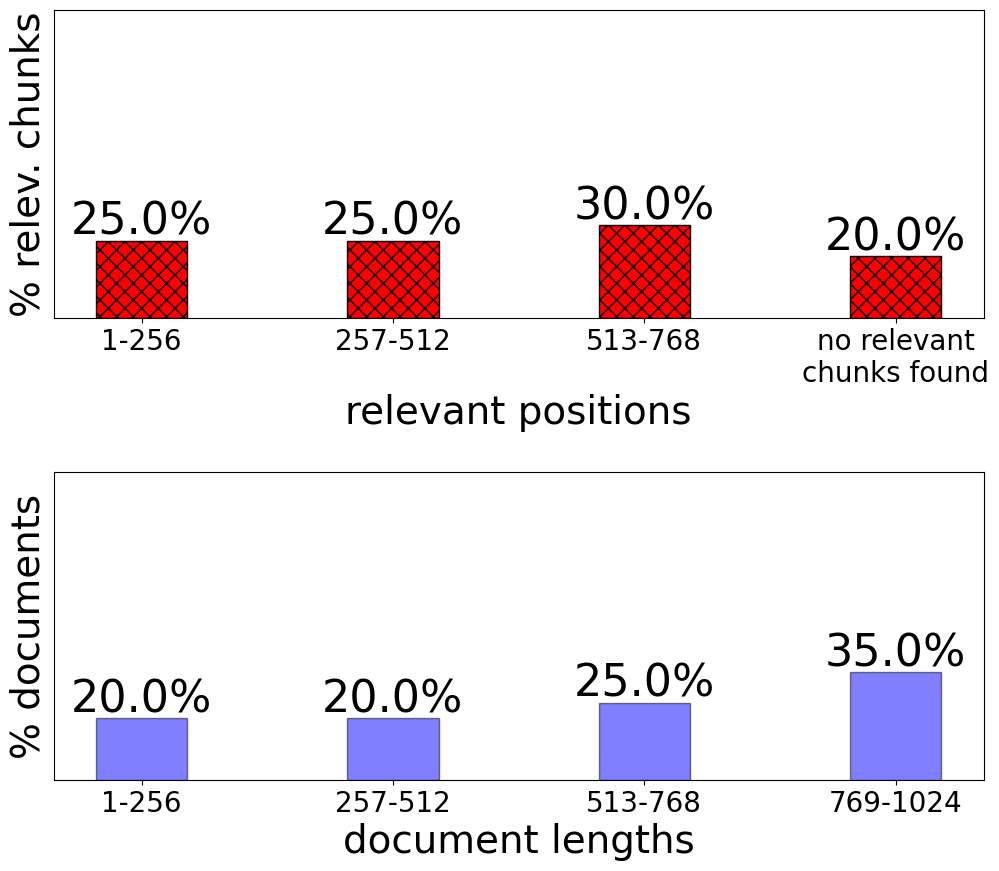

In [22]:
from utils import plot_percentage_bars_ver3

# Example usage
match_start_arr = [0, 1, 2, -1, 2, 2, 1, 0, -1, 0, 1, -1, 2, 2, 2, 0, 1, 1, -1, 0]
doc_len_arr = [0, 1, 2, 2, 3, 3, 1, 0, 2, 1, 3, 3, 3, 0, 0, 1, 2, 2, 3, 3]
max_value = 3

# Example with saving
plot_percentage_bars_ver3(match_start_arr, doc_len_arr, max_value, chunk_size=256)

In [23]:
import json
import os
from tqdm.auto import tqdm

from collections import defaultdict


for idx, (part_key, part_name_arr) in enumerate(PART_DICT.items()):

    doc_lens_dict = defaultdict(int)
    match_start_dict = defaultdict(int)
    for part_name in part_name_arr:
        for k, v in json.load(open(f'processed/{part_name}/doc_lens_dict.json')):
            if type(k) == list:
                k = tuple(k)
            doc_lens_dict[k] += v
        for k, v in json.load(open(f'processed/{part_name}/match_start_dict.json')):
            if type(k) == list:
                k = tuple(k)
            match_start_dict[k] += v

    # We don't do this any more
    # We add one to all non-negative because we look at the positions where a relevant chunk ends.
    # We don't change -1 b/c it has special meaning: no relevant are found
    #match_start_adj_arr = list(map(lambda e: e + 1 if e >= 0 else e, match_start_dict.values()))
    
    plot_percentage_bars_ver3(list(match_start_dict.values()),
                            list(doc_lens_dict.values()), max_value=4, chunk_size=256, 
                            figure_name=f'plots/{part_key}')

Figure saved as plots/msmarco_train.png
Figure saved as plots/msmarco_dev.png
Figure saved as plots/test2019-2020.png
Figure saved as plots/gov2.png
Figure saved as plots/clueweb12.png
Figure saved as plots/robust04.png


In [ ]:
#list(match_start_dict.values())